# AMD_ROCm_Stable_Diffusion 🖼️
**目标**: 最简代码实现Stable Diffusion的部署演示、和Dreambooth微调（定制输出）。

> 前置：已完成 `AMD_ROCm_Quick_Start.ipynb` 的环境验证。

In [ ]:
## 1)基础环境检查、配置、模型下载
import sys
!{sys.executable} -m pip install -q diffusers matplotlib

import os
import torch
from pathlib import Path

assert torch.cuda.is_available(), "No GPU found. Check ROCm/PyTorch env."
print("torch:", torch.__version__)
print("hip:  ", getattr(torch.version, "hip", None))
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {p.name}, {p.total_memory/1024**3:.1f} GB")

WORK_DIR        = Path("/mnt/workspace/amd/stable_diffusion_dreambooth")
MODEL_CACHE     = WORK_DIR / "models"
OUTPUT_DIR      = WORK_DIR / "outputs"
INSTANCE_DIR    = WORK_DIR / "data" / "instance"   # 把你的训练图放在这里
CLASS_DIR       = WORK_DIR / "data" / "class"      # 先验保留（可选）
LORA_OUTPUT     = OUTPUT_DIR / "lora_dreambooth"

for d in [WORK_DIR, MODEL_CACHE, OUTPUT_DIR, INSTANCE_DIR, CLASS_DIR, LORA_OUTPUT]:
    d.mkdir(parents=True, exist_ok=True)

from modelscope import snapshot_download
SD_MODEL_ID = "AI-ModelScope/stable-diffusion-v1-5"
sd_model_path = snapshot_download(SD_MODEL_ID, cache_dir=str(MODEL_CACHE))
print("模型路径:", sd_model_path)

torch: 2.10.0+git8514f05
hip:   7.2.53211
GPU 0: , 191.7 GB


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-31 15:03:47,211 - modelscope - INFO - Got 26 files, start to download ...
Processing 26 items:   0%|          | 0.00/26.0 [00:00<?, ?it/s]































Processing 26 items:   4%|▍         | 1.00/26.0 [00:00<00:13, 1.80it/s]









Processing 26 items:  12%|█▏        | 3.00/26.0 [00:00<00:04, 5.40it/s]















































































Processing 26 items:  23%|██▎       | 6.00/26.0 [00:01<00:03, 5.28it/s]





































































































Processing 26 items:  31%|███       | 8.00/26.0 [00:01<00:03, 4.88it/s]



























































































































































































































































































































































模型路径: /mnt/workspace/amd/stable_diffusion_dreambooth/models/AI-ModelScope/stable-diffusion-v1-5


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 10.02it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████| 30/30 [00:01<00:00, 19.13it/s]


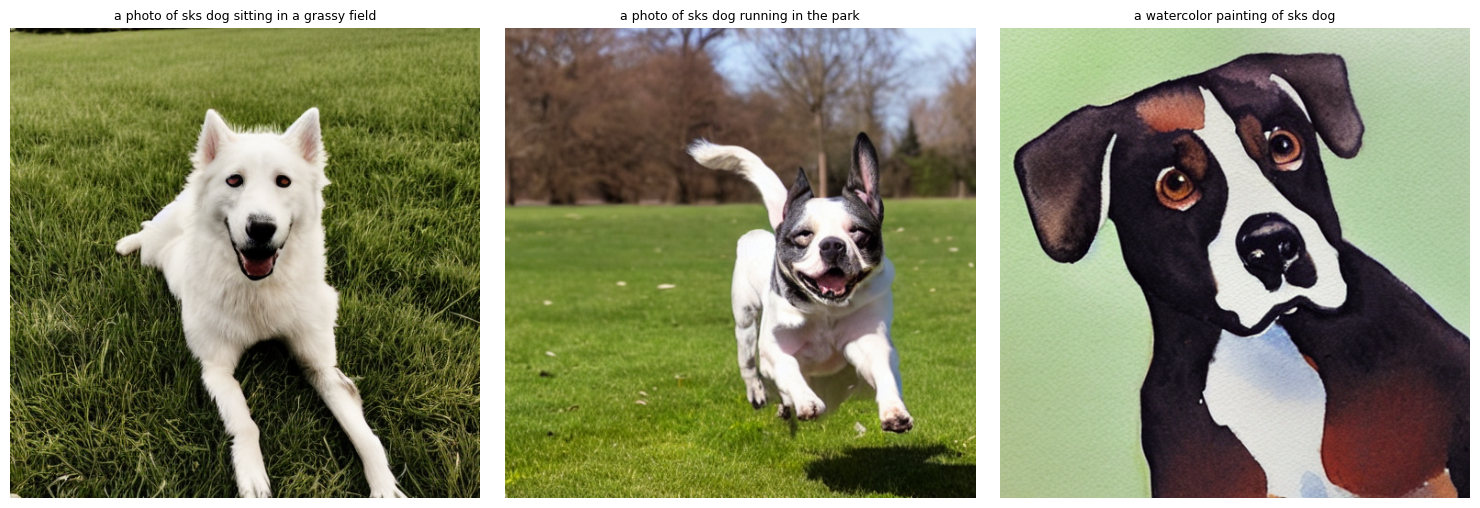

In [10]:
## 2）原始模型测试
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

# 加载基座模型
pipe = StableDiffusionPipeline.from_pretrained(
    sd_model_path, torch_dtype=torch.float16, safety_checker=None
).to("cuda")
pipe.enable_attention_slicing()

PROMPTS = [
    "a photo of sks dog sitting in a grassy field",
    "a photo of sks dog running in the park",
    "a watercolor painting of sks dog",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, p in enumerate(PROMPTS):
    img = pipe(p, num_inference_steps=30, height=512, width=512,
               generator=torch.Generator("cuda").manual_seed(42+i)).images[0]
    axes[i].imshow(img)
    axes[i].set_title(p, fontsize=9)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [14]:
## 3）dreambooth训练
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import CLIPTokenizer, CLIPTextModel
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from peft import LoraConfig, get_peft_model
from accelerate import Accelerator
from tqdm.auto import tqdm
import random

# ---------- 配置 ----------
TOKEN       = "sks"          # 专属个体：例如你家的宠物狗
CLASS       = "dog"          # 主体类别
INSTANCE_PROMPT = f"a photo of {TOKEN} {CLASS}"
CLASS_PROMPT    = f"a photo of a {CLASS}"

LR              = 1e-4
STEPS           = 800
LORA_RANK       = 4
BATCH_SIZE      = 1
GRAD_ACC        = 4          # 等效 batch = 4
RESOLUTION      = 512
PRIOR_LOSS_WEIGHT = 1.0
NUM_CLASS_IMAGES  = 50       # 先验保留：生成/收集50张同类图

# ---------- 加载组件 ----------
tokenizer    = CLIPTokenizer.from_pretrained(sd_model_path, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(sd_model_path, subfolder="text_encoder", torch_dtype=torch.float16).to("cuda")
vae          = AutoencoderKL.from_pretrained(sd_model_path, subfolder="vae", torch_dtype=torch.float16).to("cuda")
unet         = UNet2DConditionModel.from_pretrained(sd_model_path, subfolder="unet", torch_dtype=torch.float16).to("cuda")
noise_scheduler = DDPMScheduler.from_pretrained(sd_model_path, subfolder="scheduler")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# ---------- UNet 加 LoRA ----------
unet = get_peft_model(unet, LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
))
unet.print_trainable_parameters()

# ---------- 数据集 ----------
class DreamBoothDataset(Dataset):
    def __init__(self, img_dir, prompt, tokenizer, size=512):
        self.imgs = list(Path(img_dir).glob("*")) if Path(img_dir).exists() else []
        self.prompt = prompt
        self.tokenizer = tokenizer
        self.tf = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = Image.open(self.imgs[i]).convert("RGB")
        pix = self.tf(img)
        ids = self.tokenizer(
            self.prompt, padding="max_length", truncation=True,
            max_length=self.tokenizer.model_max_length, return_tensors="pt"
        ).input_ids[0]
        return {"pixel_values": pix, "input_ids": ids}

# 训练图（instance）
inst_dataset = DreamBoothDataset(INSTANCE_DIR, INSTANCE_PROMPT, tokenizer, RESOLUTION)
inst_loader  = DataLoader(inst_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 先验保留图（class）— 如果没有真实图，用基座模型生成
if CLASS_DIR.exists() and any(CLASS_DIR.iterdir()):
    class_dataset = DreamBoothDataset(CLASS_DIR, CLASS_PROMPT, tokenizer, RESOLUTION)
else:
    # 自动生成先验图（简化版：直接用基座模型生成）
    print("正在生成先验保留图片...")
    CLASS_DIR.mkdir(parents=True, exist_ok=True)
    pipe_prior = StableDiffusionPipeline.from_pretrained(
        sd_model_path, torch_dtype=torch.float16, safety_checker=None
    ).to("cuda")
    for i in range(NUM_CLASS_IMAGES):
        im = pipe_prior(CLASS_PROMPT, num_inference_steps=25, height=512, width=512).images[0]
        im.save(CLASS_DIR / f"class_{i:03d}.png")
    del pipe_prior; torch.cuda.empty_cache()
    class_dataset = DreamBoothDataset(CLASS_DIR, CLASS_PROMPT, tokenizer, RESOLUTION)

class_loader = DataLoader(class_dataset, batch_size=BATCH_SIZE, shuffle=True)
class_iter   = iter(class_loader)

# ---------- 训练 ----------
accelerator = Accelerator(mixed_precision="fp16", gradient_accumulation_steps=GRAD_ACC)
optimizer = torch.optim.AdamW(unet.parameters(), lr=LR)
unet, optimizer, inst_loader = accelerator.prepare(unet, optimizer, inst_loader)

device = next(unet.parameters()).device  # 获取当前设备
unet.train()
progress = tqdm(range(STEPS), desc="Training")

for step in progress:
    try:
        batch_inst = next(iter(inst_loader))
    except StopIteration:
        inst_loader = DataLoader(inst_dataset, batch_size=BATCH_SIZE, shuffle=True)
        inst_loader = accelerator.prepare(inst_loader)
        batch_inst = next(iter(inst_loader))

    with accelerator.accumulate(unet):
        # Instance forward
        latents = vae.encode(batch_inst["pixel_values"].to(device, dtype=torch.float16)).latent_dist.sample() * vae.config.scaling_factor
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
        encoder_hidden_states = text_encoder(batch_inst["input_ids"].to(device))[0]
        model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
        loss_inst = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")

        # Class prior
        try:
            batch_cls = next(class_iter)
        except StopIteration:
            class_iter = iter(class_loader)
            batch_cls = next(class_iter)

        latents_c = vae.encode(batch_cls["pixel_values"].to(device, dtype=torch.float16)).latent_dist.sample() * vae.config.scaling_factor
        noise_c = torch.randn_like(latents_c)
        timesteps_c = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents_c.shape[0],), device=device).long()
        noisy_latents_c = noise_scheduler.add_noise(latents_c, noise_c, timesteps_c)
        encoder_hidden_states_c = text_encoder(batch_cls["input_ids"].to(device))[0]
        model_pred_c = unet(noisy_latents_c, timesteps_c, encoder_hidden_states_c).sample
        loss_cls = F.mse_loss(model_pred_c.float(), noise_c.float(), reduction="mean")

        loss = loss_inst + PRIOR_LOSS_WEIGHT * loss_cls
        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

    progress.set_postfix({"loss": loss.item(), "inst": loss_inst.item(), "cls": loss_cls.item()})
    
# 保存 LoRA 权重
accelerator.wait_for_everyone()
unwrapped_unet = accelerator.unwrap_model(unet)
unwrapped_unet.save_pretrained(LORA_OUTPUT)
print("LoRA 权重已保存到:", LORA_OUTPUT)

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 6412.11it/s]


trainable params: 797,184 || all params: 860,318,148 || trainable%: 0.0927


Training: 100%|██████████| 800/800 [03:56<00:00,  3.38it/s, loss=0.32, inst=0.0881, cls=0.232]      

LoRA 权重已保存到: /mnt/workspace/amd/stable_diffusion_dreambooth/outputs/lora_dreambooth


100%|██████████| 50/50 [00:03<00:00, 15.79it/s]


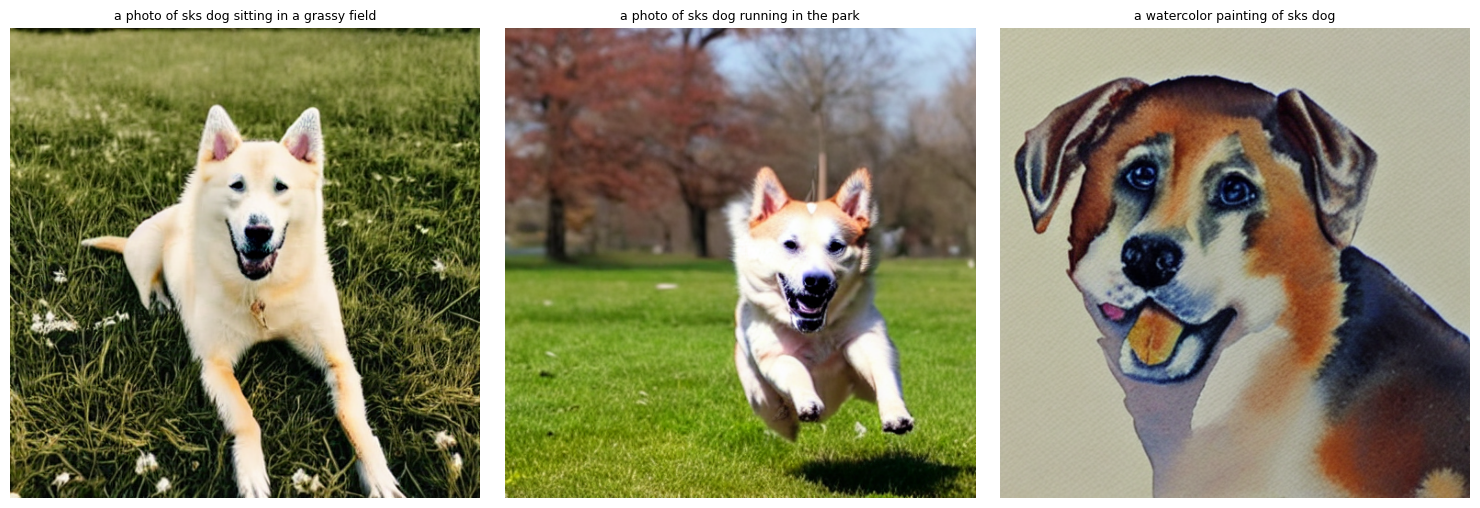

In [15]:
## 4）dreambooth预测
from peft import PeftModel
pipe.unet = PeftModel.from_pretrained(pipe.unet, str(LORA_OUTPUT))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, p in enumerate(PROMPTS):
    img = pipe(p, num_inference_steps=50, height=512, width=512,
               generator=torch.Generator("cuda").manual_seed(42+i)).images[0]
    axes[i].imshow(img)
    axes[i].set_title(p, fontsize=9)
    axes[i].axis("off")
plt.tight_layout()
plt.show()